<a href="https://colab.research.google.com/github/Sona-28/Sentiment-and-Sarcasm-Classification-COMM061/blob/main/NLP_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    RocCurveDisplay
)


from datasets import Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
    DataCollatorWithPadding

)

import torch

import joblib

## Loading the data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_df = joblib.load('drive/MyDrive/nlp/train_df.pkl')
val_df = joblib.load('drive/MyDrive/nlp/val_df.pkl')
test_df = joblib.load('drive/MyDrive/nlp/test_df.pkl')

train_val_df = pd.concat([train_df, val_df])

In [5]:
train_df.head()

,text,variety,source,Sentiment,Sarcasm,tokens,clean_text
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0,"[member, but, vote, lib, dem, so, tight, tory,...",member but vote lib dem so tight tory not cont...
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0,"[yeah, blow, 3x, what, budget, who, would, ve,...",yeah blow 3x what budget who would ve think gi...
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0,"[food, pretty, great, little, dry, but, sucker...",food pretty great little dry but sucker load d...
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0,"[firstly, staff, they, want, cheese, ham, toas...",firstly staff they want cheese ham toasty orde...
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0,"[we, come, lunch, enjoy, food, we, order, hot,...",we come lunch enjoy food we order hot taste fr...


# Baseline model

### Compute metrics for baseline

In [6]:
def compute_metrics_baseline(y_test, y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  precision, recall, macro_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
  _, _, weighted_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
  cls_report = classification_report(y_test, y_pred)
  return {
      'accuracy': accuracy,
      'precision': precision,
      'recall': recall,
      'macro_f1': macro_f1,
      'weighted_f1': weighted_f1,
      'classification_report': cls_report
  }

def plot_conf_matrix(y_test, y_pred):
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

def plot_roc_curve(y_test, y_prob):
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)
  plt.title('ROC Curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
  plt.plot([0, 1], [0,1], linestyle='--', label='Random baseline')
  plt.legend()
  plt.grid(True)
  plt.show()

## 1. TF-IDF + LR

In [7]:
def fine_tune_tfidf_lr(X_train, y_train):

  pipeline = Pipeline([
      ('tfidf', TfidfVectorizer()),
      ('clf', LogisticRegression(random_state=100))
  ])
  param_grid = {
      'tfidf__max_features': [5000, 10000],
      'tfidf__ngram_range': [(1,1), (1,2)],
      'clf__C': [0.1, 1.0, 2.0],
      'clf__class_weight': [None, 'balanced'],
      'clf__solver': ['liblinear', 'lbfgs'],
      'clf__max_iter': [500, 1000]
  }

  grid_search = GridSearchCV(
      pipeline,
      param_grid,
      cv=5,
      scoring='f1_macro',
      n_jobs=-1,
      verbose=1
  )

  grid_search.fit(X_train, y_train)

  best_model = grid_search.best_estimator_
  best_params = grid_search.best_params_

  return best_model, best_params


In [8]:
X_train = train_val_df['clean_text']

y_train_sent = train_val_df['Sentiment']

y_train_sarc = train_val_df['Sarcasm']

best_sent_lr_model, best_sent_lr_params = fine_tune_tfidf_lr(X_train, y_train_sent)
best_sarc_lr_model, best_sarc_lr_params = fine_tune_tfidf_lr(X_train, y_train_sarc)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [9]:
best_sent_lr_params

{'clf__C': 2.0,
 'clf__class_weight': None,
 'clf__max_iter': 500,
 'clf__solver': 'liblinear',
 'tfidf__max_features': 10000,
 'tfidf__ngram_range': (1, 2)}

In [10]:
best_sarc_lr_params

{'clf__C': 1.0,
 'clf__class_weight': 'balanced',
 'clf__max_iter': 500,
 'clf__solver': 'lbfgs',
 'tfidf__max_features': 10000,
 'tfidf__ngram_range': (1, 1)}

### Running with best parameters

In [11]:
sent_lr_vectorizer = TfidfVectorizer(
    max_features=best_sent_lr_params['tfidf__max_features'],
    ngram_range=best_sent_lr_params['tfidf__ngram_range']
)

X_train_sent = sent_lr_vectorizer.fit_transform(train_val_df['clean_text'])
X_test_sent = sent_lr_vectorizer.transform(test_df['clean_text'])
y_train_sent = train_val_df['Sentiment']
y_test_sent = test_df['Sentiment']

sarc_lr_vectorizer = TfidfVectorizer(
    max_features=best_sarc_lr_params['tfidf__max_features'],
    ngram_range=best_sarc_lr_params['tfidf__ngram_range']
)

X_train_sarc = sarc_lr_vectorizer.fit_transform(train_val_df['clean_text'])
X_test_sarc = sarc_lr_vectorizer.transform(test_df['clean_text'])
y_train_sarc = train_val_df['Sarcasm']
y_test_sarc = test_df['Sarcasm']

In [12]:
sentiment_results = {}
sarcasm_results = {}

seeds = [42, 100]

for seed in seeds:
  set_seed(seed)
  sent_model = LogisticRegression(
      C=best_sent_lr_params['clf__C'],
      class_weight = best_sent_lr_params['clf__class_weight'],
      solver = best_sent_lr_params['clf__solver'],
      max_iter=best_sent_lr_params['clf__max_iter'],
      random_state=seed,
  )

  sent_model.fit(X_train_sent, y_train_sent)
  y_pred_sent = sent_model.predict(X_test_sent)
  sentiment_results[seed] = compute_metrics_baseline(y_test_sent, y_pred_sent)

  sarc_model = LogisticRegression(
      C=best_sarc_lr_params['clf__C'],
      class_weight = best_sarc_lr_params['clf__class_weight'],
      solver = best_sarc_lr_params['clf__solver'],
      max_iter = best_sarc_lr_params['clf__max_iter'],
      random_state=seed,
  )

  sarc_model.fit(X_train_sarc, y_train_sarc)
  y_pred_sarc = sarc_model.predict(X_test_sarc)
  sarcasm_results[seed] = compute_metrics_baseline(y_test_sarc, y_pred_sarc)

  print(f'Seed {seed} done')




Seed 42 done
Seed 100 done


In [13]:
sentiment_results_pd = pd.DataFrame(sentiment_results).T
sentiment_results_pd

,accuracy,precision,recall,macro_f1,weighted_f1,classification_report
42,0.835089,0.837012,0.834164,0.834511,0.83474,precision recall f1-score ...
100,0.835089,0.837012,0.834164,0.834511,0.83474,precision recall f1-score ...


In [14]:
sarcasm_results_pd = pd.DataFrame(sarcasm_results).T
sarcasm_results_pd


,accuracy,precision,recall,macro_f1,weighted_f1,classification_report
42,0.744388,0.615919,0.700396,0.62407,0.777318,precision recall f1-score ...
100,0.744388,0.615919,0.700396,0.62407,0.777318,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy: 0.8350893266147503
Macro F1 0.8345114436174836
Weighted F1 0.834739908988496
Precision 0.8370119255331763
Recall 0.8341640618045185
Classification Report
              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84      1117
         1.0       0.86      0.79      0.82      1066

    accuracy                           0.84      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.84      0.84      0.83      2183



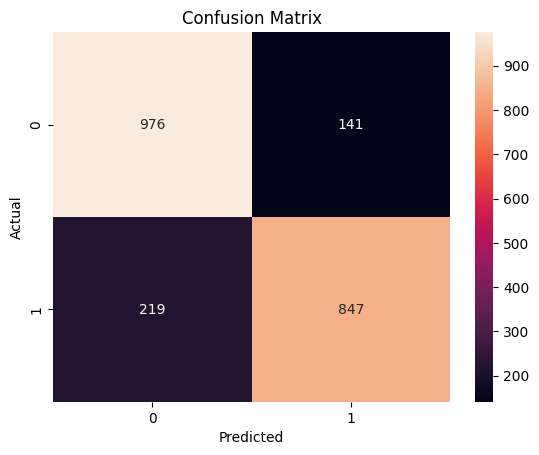

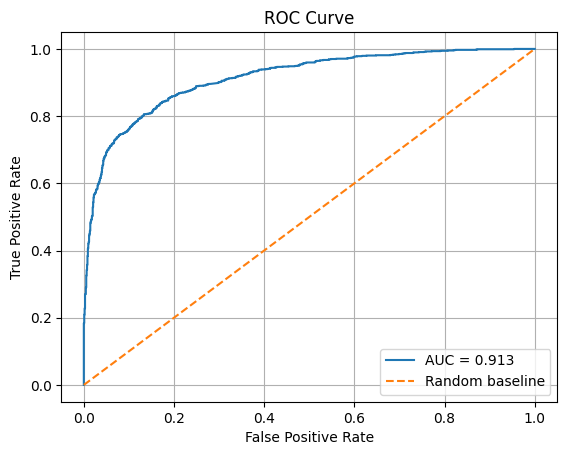

In [15]:
sentiment_best_result_lr = sentiment_results[42]
print("Best Sentiment Model Metrics")
print("Accuracy:", sentiment_best_result_lr['accuracy'])
print("Macro F1", sentiment_best_result_lr['macro_f1'])
print("Weighted F1", sentiment_best_result_lr['weighted_f1'])
print("Precision", sentiment_best_result_lr['precision'])
print("Recall", sentiment_best_result_lr['recall'])
print("Classification Report")
print(sentiment_best_result_lr['classification_report'])
plot_conf_matrix(y_test_sent, y_pred_sent)
y_prob_sent = sent_model.predict_proba(X_test_sent)[:, 1]
plot_roc_curve(y_test_sent, y_prob_sent)

Best Sarcasm Model Metrics
Accuracy: 0.744388456252863
Macro F1 0.624069520261312
Weighted F1 0.7773178492610769
Precision 0.6159186847367252
Recall 0.7003963058014282
Classification Report
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.84      1878
         1.0       0.30      0.64      0.41       305

    accuracy                           0.74      2183
   macro avg       0.62      0.70      0.62      2183
weighted avg       0.84      0.74      0.78      2183



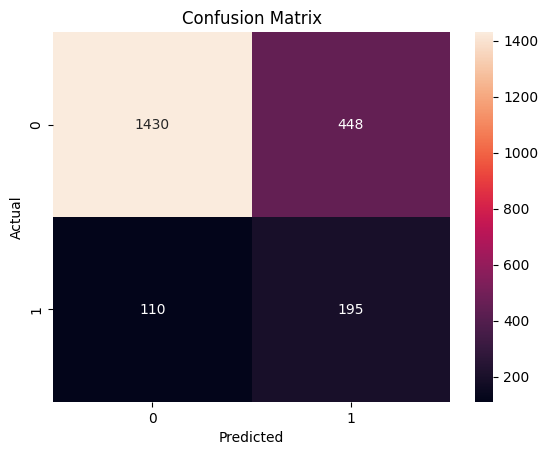

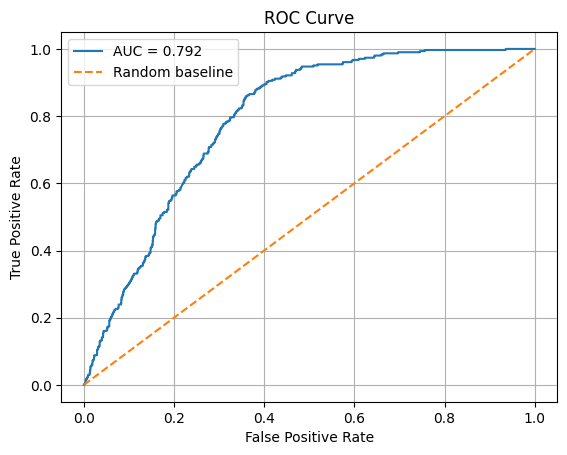

In [16]:
sarcasm_best_result_lr = sarcasm_results[42]
print("Best Sarcasm Model Metrics")
print("Accuracy:", sarcasm_best_result_lr['accuracy'])
print("Macro F1", sarcasm_best_result_lr['macro_f1'])
print("Weighted F1", sarcasm_best_result_lr['weighted_f1'])
print("Precision", sarcasm_best_result_lr['precision'])
print("Recall", sarcasm_best_result_lr['recall'])
print("Classification Report")
print(sarcasm_best_result_lr['classification_report'])
plot_conf_matrix(y_test_sarc, y_pred_sarc)
y_prob_sarc = sarc_model.predict_proba(X_test_sarc)[:, 1]
plot_roc_curve(y_test_sarc, y_prob_sarc)

## 2. TF-IDF + Linear SVC

In [17]:
def fine_tune_tfidf_svm(X_train, y_train):
  pipeline = Pipeline([
      ('tfidf', TfidfVectorizer()),
      ('clf', LinearSVC())
  ])

  param_grid = {
      'tfidf__max_features': [5000, 10000],
      'tfidf__ngram_range': [(1,1), (1,2)],
      'clf__C': [0.1, 1.0, 2.0],
      'clf__class_weight': [None, 'balanced'],
      'clf__max_iter': [500, 1000]
  }

  grid_search = GridSearchCV(
      pipeline,
      param_grid,
      cv=5,
      scoring='f1_macro',
      n_jobs=-1,
      verbose=1
  )

  grid_search.fit(X_train, y_train)

  best_params = grid_search.best_params_

  return best_params

In [18]:
best_sent_svm_params = fine_tune_tfidf_svm(X_train, y_train_sent)
best_sarc_svm_params = fine_tune_tfidf_svm(X_train, y_train_sarc)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [19]:
best_sent_svm_params

{'clf__C': 0.1,
 'clf__class_weight': None,
 'clf__max_iter': 500,
 'tfidf__max_features': 5000,
 'tfidf__ngram_range': (1, 2)}

In [20]:
best_sarc_svm_params

{'clf__C': 0.1,
 'clf__class_weight': 'balanced',
 'clf__max_iter': 500,
 'tfidf__max_features': 10000,
 'tfidf__ngram_range': (1, 1)}

### Running with best parameters

In [21]:
sent_svc_vectorizer = TfidfVectorizer(
    max_features=best_sent_svm_params['tfidf__max_features'],
    ngram_range=best_sent_svm_params['tfidf__ngram_range']
)
X_train_sent = sent_svc_vectorizer.fit_transform(train_val_df['clean_text'])
X_test_sent = sent_svc_vectorizer.transform(test_df['clean_text'])
y_train_sent = train_val_df['Sentiment']
y_test_sent = test_df['Sentiment']

sarc_svc_vectorizer = TfidfVectorizer(
    max_features=best_sarc_svm_params['tfidf__max_features'],
    ngram_range=best_sarc_svm_params['tfidf__ngram_range']
)
X_train_sarc = sarc_svc_vectorizer.fit_transform(train_val_df['clean_text'])
X_test_sarc = sarc_svc_vectorizer.transform(test_df['clean_text'])
y_train_sarc = train_val_df['Sarcasm']
y_test_sarc = test_df['Sarcasm']

In [22]:
sentiment_results = {}
sarcasm_results = {}

seeds = [42, 100]

for seed in seeds:
  set_seed(seed)
  sent_model = LinearSVC(
      C=best_sent_svm_params['clf__C'],
      class_weight = best_sent_svm_params['clf__class_weight'],
      max_iter=best_sent_svm_params['clf__max_iter'],
      random_state=seed
  )
  sent_model.fit(X_train_sent, y_train_sent)
  y_pred_sent = sent_model.predict(X_test_sent)
  sentiment_results[seed] = compute_metrics_baseline(y_test_sent, y_pred_sent)

  sarc_model = LinearSVC(
      C=best_sarc_svm_params['clf__C'],
      class_weight = best_sarc_svm_params['clf__class_weight'],
      max_iter=best_sarc_svm_params['clf__max_iter'],
      random_state=seed
  )
  sarc_model.fit(X_train_sarc, y_train_sarc)
  y_pred_sarc = sarc_model.predict(X_test_sarc)
  sarcasm_results[seed] = compute_metrics_baseline(y_test_sarc, y_pred_sarc)
  print(f'Seed {seed} done')


Seed 42 done
Seed 100 done


In [23]:
pd.DataFrame(sentiment_results).T

,accuracy,precision,recall,macro_f1,weighted_f1,classification_report
42,0.829592,0.832892,0.828386,0.828729,0.829013,precision recall f1-score ...
100,0.829592,0.832892,0.828386,0.828729,0.829013,precision recall f1-score ...


In [24]:
pd.DataFrame(sarcasm_results).T

,accuracy,precision,recall,macro_f1,weighted_f1,classification_report
42,0.731104,0.611061,0.698168,0.615222,0.767378,precision recall f1-score ...
100,0.731104,0.611061,0.698168,0.615222,0.767378,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy: 0.8295923041685753
Macro F1 0.8287288483050804
Weighted F1 0.8290129531375853
Precision 0.832892332892333
Recall 0.8283856349340988
Classification Report
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84      1117
         1.0       0.86      0.78      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



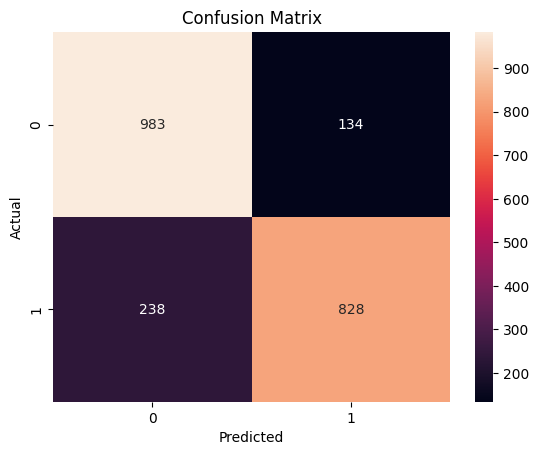

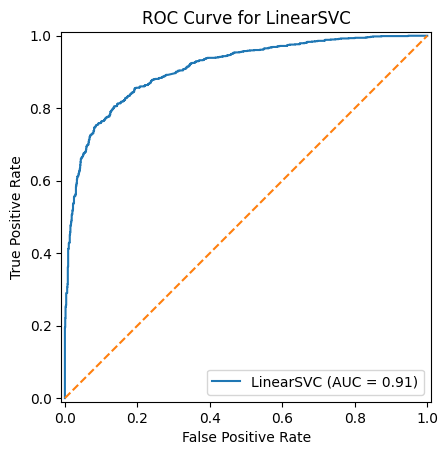

In [25]:
sentiment_best_result_svc = sentiment_results[42]
print("Best Sentiment Model Metrics")
print("Accuracy:", sentiment_best_result_svc['accuracy'])
print("Macro F1", sentiment_best_result_svc['macro_f1'])
print("Weighted F1", sentiment_best_result_svc['weighted_f1'])
print("Precision", sentiment_best_result_svc['precision'])
print("Recall", sentiment_best_result_svc['recall'])
print("Classification Report")
print(sentiment_best_result_svc['classification_report'])
plot_conf_matrix(y_test_sent, y_pred_sent)

y_score_sent = sent_model.decision_function(X_test_sent)

fpr, tpr, thresholds = roc_curve(y_test_sent, y_score_sent)
roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='LinearSVC')
display.plot()
plt.plot([0, 1], [0,1], linestyle='--', label='Random baseline')
plt.title('ROC Curve for LinearSVC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


Best Sarcasm Model Metrics
Accuracy: 0.7311039853412735
Macro F1 0.6152218203547144
Weighted F1 0.7673776179539276
Precision 0.6110607216938672
Recall 0.6981677403585956
Classification Report
              precision    recall  f1-score   support

         0.0       0.93      0.74      0.83      1878
         1.0       0.29      0.65      0.40       305

    accuracy                           0.73      2183
   macro avg       0.61      0.70      0.62      2183
weighted avg       0.84      0.73      0.77      2183



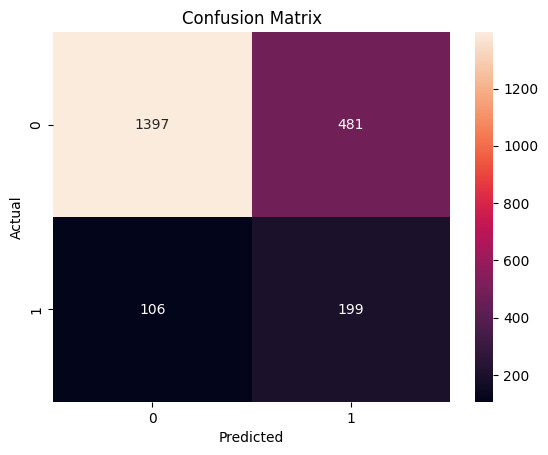

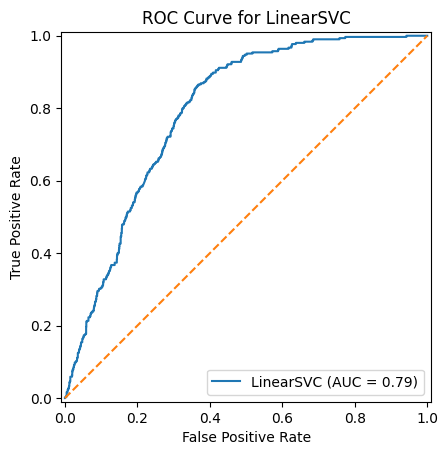

In [26]:
sarcasm_best_result_svc = sarcasm_results[42]
print("Best Sarcasm Model Metrics")
print("Accuracy:", sarcasm_best_result_svc['accuracy'])
print("Macro F1", sarcasm_best_result_svc['macro_f1'])
print("Weighted F1", sarcasm_best_result_svc['weighted_f1'])
print("Precision", sarcasm_best_result_svc['precision'])
print("Recall", sarcasm_best_result_svc['recall'])
print("Classification Report")
print(sarcasm_best_result_svc['classification_report'])
plot_conf_matrix(y_test_sarc, y_pred_sarc)

y_score_sarc = sarc_model.decision_function(X_test_sarc)

fpr, tpr, thresholds = roc_curve(y_test_sarc, y_score_sarc)
roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='LinearSVC')
display.plot()
plt.plot([0, 1], [0,1], linestyle='--', label='Random baseline')
plt.title('ROC Curve for LinearSVC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

## 3. TF-IDF + Naive Bayes

In [27]:
def fine_tune_tfidf_nb(X_train, y_train):
  pipeline = Pipeline([
      ('tfidf', TfidfVectorizer()),
      ('clf', MultinomialNB())
  ])

  param_grid = {
      'tfidf__max_features': [5000, 10000],
      'tfidf__ngram_range': [(1,1), (1,2)],
      'clf__alpha': [0.1, 0.5, 1.0, 2.0],
      'clf__fit_prior': [True, False]
  }

  grid_search = GridSearchCV(
      pipeline,
      param_grid,
      cv=5,
      scoring='f1_macro',
      n_jobs=-1,
      verbose=1
  )
  grid_search.fit(X_train, y_train)

  best_model = grid_search.best_estimator_
  best_params = grid_search.best_params_

  return best_model, best_params

In [28]:
best_sent_nb_model, best_sent_nb_params = fine_tune_tfidf_nb(X_train, y_train_sent)
best_sarc_nb_model, best_sarc_nb_params = fine_tune_tfidf_nb(X_train, y_train_sarc)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [29]:
best_sent_nb_params

{'clf__alpha': 0.5,
 'clf__fit_prior': True,
 'tfidf__max_features': 10000,
 'tfidf__ngram_range': (1, 2)}

In [30]:
best_sarc_nb_params

{'clf__alpha': 0.1,
 'clf__fit_prior': False,
 'tfidf__max_features': 10000,
 'tfidf__ngram_range': (1, 2)}

Best Sentiment Model Metrics
Accuracy 0.8085203847915712
Macro F1 0.8085087719298245
Weighted F1 0.8085436105150645
Precision 0.8086300679929489
Recall 0.8087798831297314
Classification Report
              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81      1117
         1.0       0.79      0.82      0.81      1066

    accuracy                           0.81      2183
   macro avg       0.81      0.81      0.81      2183
weighted avg       0.81      0.81      0.81      2183



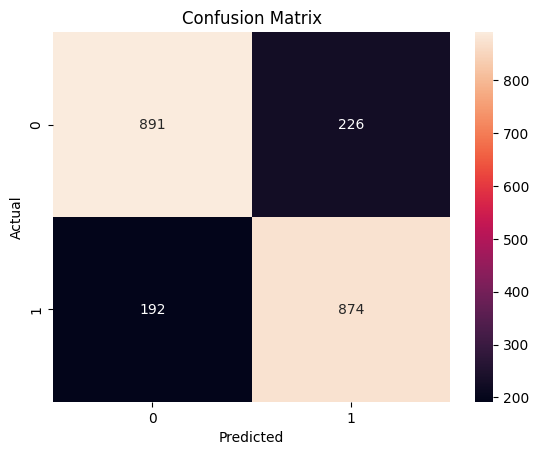

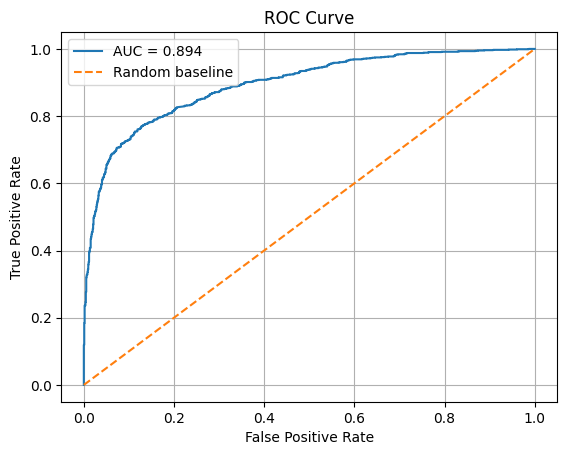

In [31]:
y_pred_sent = best_sent_nb_model.predict(test_df['clean_text'])
sentiment_best_result_nb = compute_metrics_baseline(y_test_sent, y_pred_sent)
print("Best Sentiment Model Metrics")
print("Accuracy",sentiment_best_result_nb['accuracy'])
print("Macro F1", sentiment_best_result_nb['macro_f1'])
print("Weighted F1", sentiment_best_result_nb['weighted_f1'])
print("Precision", sentiment_best_result_nb['precision'])
print("Recall", sentiment_best_result_nb['recall'])
print("Classification Report")
print(sentiment_best_result_nb['classification_report'])
plot_conf_matrix(y_test_sent, y_pred_sent)
y_prob_sent = best_sent_nb_model.predict_proba(test_df['clean_text'])[:, 1]
plot_roc_curve(y_test_sent, y_prob_sent)

Best Sarcasm Model Metrics
Accuracy 0.7311039853412735
Macro F1 0.6118539802489195
Weighted F1 0.7668789868689797
Precision 0.6074973814746744
Recall 0.689929118874282
Classification Report
              precision    recall  f1-score   support

         0.0       0.93      0.75      0.83      1878
         1.0       0.29      0.63      0.40       305

    accuracy                           0.73      2183
   macro avg       0.61      0.69      0.61      2183
weighted avg       0.84      0.73      0.77      2183



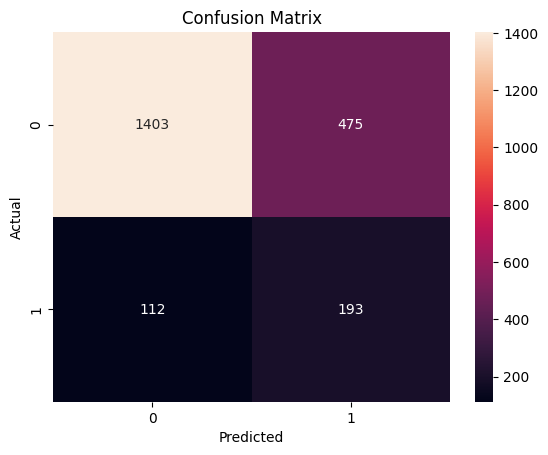

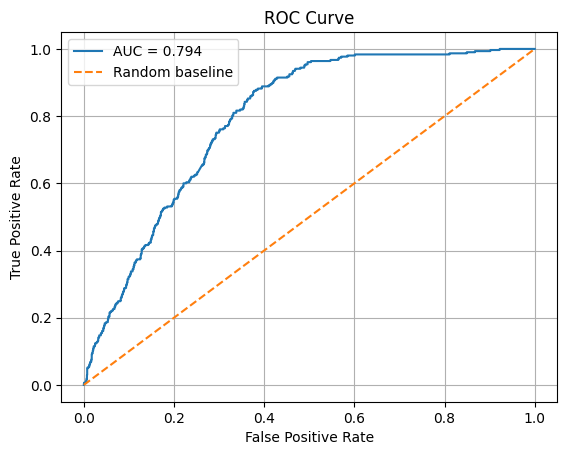

In [32]:
y_pred_sarc = best_sarc_nb_model.predict(test_df['clean_text'])
sarcasm_best_result_nb = compute_metrics_baseline(y_test_sarc, y_pred_sarc)
print("Best Sarcasm Model Metrics")
print("Accuracy",sarcasm_best_result_nb['accuracy'])
print("Macro F1", sarcasm_best_result_nb['macro_f1'])
print("Weighted F1", sarcasm_best_result_nb['weighted_f1'])
print("Precision", sarcasm_best_result_nb['precision'])
print("Recall", sarcasm_best_result_nb['recall'])
print("Classification Report")
print(sarcasm_best_result_nb['classification_report'])
plot_conf_matrix(y_test_sarc, y_pred_sarc)
y_prob_sarc = best_sarc_nb_model.predict_proba(test_df['clean_text'])[:, 1]
plot_roc_curve(y_test_sarc, y_prob_sarc)

# Transfomers

## Compute Metrics function for Transformer

In [49]:
def compute_metrics_transfomer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, preds)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    _, _, weighted_f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    cls_report = classification_report(labels, preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'classification_report': cls_report
    }

## Fine-tuning function for transfomer

In [50]:
def fine_tune_transformer(model_name, train_dataset, val_dataset, candidate_config):
  results = []
  tokenizer = AutoTokenizer.from_pretrained(model_name)

  def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128
    )

  train_df = train_dataset.map(tokenize, batched=True)
  val_df = val_dataset.map(tokenize, batched=True)

  for config in candidate_config:
    print(config)
    set_seed(42)
    model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=2,
      problem_type="single_label_classification"
    )
    training_args = TrainingArguments(
        output_dir=f"./results/lr_{config['learning_rate']}_wd_{config['weight_decay']}_ep_{config['num_train_epochs']}",
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        dataloader_pin_memory=True,
        learning_rate=config['learning_rate'],
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=config['num_train_epochs'],
        weight_decay=config['weight_decay'],
        seed=42,
        warmup_ratio=0.1,
        lr_scheduler_type="linear"
    )

    trainer = Trainer(
        model = model,
        args = training_args,
        train_dataset = train_df,
        eval_dataset = val_df,
        data_collator=DataCollatorWithPadding(tokenizer),
        processing_class = tokenizer,
        compute_metrics = compute_metrics_transfomer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    trainer.train()

    pred_output = trainer.predict(val_df)
    eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
    results.append({
        "learning_rate" : config['learning_rate'],
        "weight_decay" : config['weight_decay'],
        "num_train_epochs" : config['num_train_epochs'],
        "macro_f1" : eval_result['macro_f1'],
        "weighted_f1" : eval_result['weighted_f1'],
        "accuracy" : eval_result['accuracy'],
        "precision" : eval_result['precision'],
        "recall" : eval_result['recall'],
        "classification_report" : eval_result['classification_report']
    })

    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

  return results


## Preparing data

In [91]:
train_df['Sentiment'] = train_df['Sentiment'].map({0.0: 0, 1.0: 1})
train_df['Sarcasm'] = train_df['Sarcasm'].map({0.0: 0, 1.0: 1})
val_df['Sentiment'] = val_df['Sentiment'].map({0.0: 0, 1.0: 1})
val_df['Sarcasm'] = val_df['Sarcasm'].map({0.0: 0, 1.0: 1})
test_df['Sentiment'] = test_df['Sentiment'].map({0.0: 0, 1.0: 1})
test_df['Sarcasm'] = test_df['Sarcasm'].map({0.0: 0, 1.0: 1})
train_val_df = pd.concat([train_df, val_df])

In [92]:
train_ds_sent = Dataset.from_pandas(train_df[["text", "Sentiment"]])
val_ds_sent = Dataset.from_pandas(val_df[["text", "Sentiment"]])
test_ds_sent = Dataset.from_pandas(test_df[["text", "Sentiment"]])
train_val_ds_sent = Dataset.from_pandas(train_val_df[["text", "Sentiment"]])

train_ds_sarc = Dataset.from_pandas(train_df[["text", "Sarcasm"]])
val_ds_sarc = Dataset.from_pandas(val_df[["text", "Sarcasm"]])
test_ds_sarc = Dataset.from_pandas(test_df[["text", "Sarcasm"]])
train_val_ds_sarc = Dataset.from_pandas(train_val_df[["text", "Sarcasm"]])


In [93]:
train_ds_sent = train_ds_sent.rename_column("Sentiment", "label")
val_ds_sent   = val_ds_sent.rename_column("Sentiment", "label")
test_ds_sent  = test_ds_sent.rename_column("Sentiment", "label")
train_val_ds_sent = train_val_ds_sent.rename_column("Sentiment", "label")

train_ds_sarc = train_ds_sarc.rename_column("Sarcasm", "label")
val_ds_sarc   = val_ds_sarc.rename_column("Sarcasm", "label")
test_ds_sarc  = test_ds_sarc.rename_column("Sarcasm", "label")
train_val_ds_sarc = train_val_ds_sarc.rename_column("Sarcasm", "label")

## Candidate config setup

In [54]:
param_grid = {
    "learning_rate": [1e-5, 2e-5],
    "num_train_epochs": [2, 3],
    "weight_decay": [0.01, 0.1]
}

candidate_config = list(ParameterGrid(param_grid))

## Roberta-base

### Fine-tuning for Sentiment

In [55]:
sent_roberta_results = fine_tune_transformer('roberta-base', train_ds_sent, val_ds_sent, candidate_config)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

{'learning_rate': 1e-05, 'num_train_epochs': 2, 'weight_decay': 0.01}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1,Classification Report
1,No log,0.212049,0.913738,0.915228,0.914481,0.913724,0.913699,precision recall f1-score support 0 0.95 0.88 0.91 160 1 0.88 0.95 0.91 153 accuracy 0.91 313 macro avg 0.92 0.91 0.91 313 weighted avg 0.92 0.91 0.91 313
2,0.443654,0.216523,0.936102,0.936035,0.936213,0.936086,0.936109,precision recall f1-score support 0 0.94 0.93 0.94 160 1 0.93 0.94 0.94 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313
3,0.286465,0.272961,0.936102,0.936035,0.936213,0.936086,0.936109,precision recall f1-score support 0 0.94 0.93 0.94 160 1 0.93 0.94 0.94 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [71]:
sent_roberta_results.sort(key=lambda x: x['macro_f1'], reverse=True)
pd.DataFrame(sent_roberta_results)

,learning_rate,weight_decay,num_train_epochs,macro_f1,weighted_f1,accuracy,precision,recall,classification_report
0,0.00001,0.01,2,0.939257,0.939292,0.939297,0.939339,0.939195,precision recall f1-score ...
1,0.00001,0.10,2,0.939257,0.939292,0.939297,0.939339,0.939195,precision recall f1-score ...
2,0.00002,0.10,3,0.936086,0.936109,0.936102,0.936035,0.936213,precision recall f1-score ...
3,0.00001,0.10,3,0.936070,0.936102,0.936102,0.936070,0.936070,precision recall f1-score ...
4,0.00002,0.10,2,0.932809,0.932866,0.932907,0.933579,0.932516,precision recall f1-score ...
5,0.00002,0.01,3,0.929695,0.929720,0.929712,0.929645,0.929820,precision recall f1-score ...
6,0.00002,0.01,2,0.923303,0.923331,0.923323,0.923254,0.923427,precision recall f1-score ...
7,0.00001,0.01,3,0.904145,0.904124,0.904153,0.905317,0.904820,precision recall f1-score ...


### Fine-tuning for Sarcasm

In [69]:
sarc_roberta_results = fine_tune_transformer('roberta-base', train_ds_sarc, val_ds_sarc, candidate_config)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

{'learning_rate': 1e-05, 'num_train_epochs': 2, 'weight_decay': 0.01}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1,Classification Report
1,No log,0.479922,0.859425,0.429712,0.500000,0.462199,0.794451,precision recall f1-score support 0 0.86 1.00 0.92 269 1 0.00 0.00 0.00 44 accuracy 0.86 313 macro avg 0.43 0.50 0.46 313 weighted avg 0.74 0.86 0.79 313
2,0.401622,0.346171,0.846645,0.658145,0.606624,0.623345,0.831820,precision recall f1-score support 0 0.89 0.94 0.91 269 1 0.43 0.27 0.33 44 accuracy 0.85 313 macro avg 0.66 0.61 0.62 313 weighted avg 0.82 0.85 0.83 313
3,0.307084,0.520919,0.849840,0.672615,0.627492,0.644017,0.838598,precision recall f1-score support 0 0.89 0.94 0.91 269 1 0.45 0.32 0.37 44 accuracy 0.85 313 macro avg 0.67 0.63 0.64 313 weighted avg 0.83 0.85 0.84 313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [72]:
sarc_roberta_results.sort(key=lambda x: x['macro_f1'], reverse=True)
pd.DataFrame(sarc_roberta_results)

,learning_rate,weight_decay,num_train_epochs,macro_f1,weighted_f1,accuracy,precision,recall,classification_report
0,0.00001,0.01,3,0.692448,0.858437,0.865815,0.718111,0.674806,precision recall f1-score ...
1,0.00001,0.10,3,0.681617,0.854183,0.862620,0.709361,0.663442,precision recall f1-score ...
2,0.00002,0.10,3,0.644017,0.838598,0.849840,0.672615,0.627492,precision recall f1-score ...
3,0.00002,0.01,2,0.639039,0.838828,0.853035,0.677757,0.619846,precision recall f1-score ...
4,0.00001,0.01,2,0.637044,0.841271,0.859425,0.694637,0.614059,precision recall f1-score ...
5,0.00001,0.10,2,0.623929,0.836399,0.856230,0.682234,0.602695,precision recall f1-score ...
6,0.00002,0.10,2,0.623345,0.831820,0.846645,0.658145,0.606624,precision recall f1-score ...
7,0.00002,0.01,3,0.620546,0.834056,0.853035,0.672073,0.600836,precision recall f1-score ...


### Running the best Sentiment and Sarcasm Roberta model

In [104]:
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128
    )

train_df_sent = train_val_ds_sent.map(tokenize, batched=True)
test_df_sent = test_ds_sent.map(tokenize, batched=True)
train_df_sarc = train_val_ds_sarc.map(tokenize, batched=True)
test_df_sarc = test_ds_sarc.map(tokenize, batched=True)

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

#### Sentiment

In [99]:
sentiment_results = {}

seeds = [42,100]

for seed in seeds:
  set_seed(seed)
  model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    problem_type="single_label_classification"
  )

  training_args = TrainingArguments(
      output_dir=f"./results/bert_sentiment_seed{seed}",
      eval_strategy='no',
      learning_rate=sent_roberta_results[0]['learning_rate'],
      per_device_train_batch_size=8,
      per_device_eval_batch_size=16,
      num_train_epochs=sent_roberta_results[0]['num_train_epochs'],
      weight_decay=sent_roberta_results[0]['weight_decay'],
      seed=seed
  )

  trainer = Trainer(
      model = model,
      args = training_args,
      train_dataset = train_df_sent,
      data_collator=DataCollatorWithPadding(tokenizer),
      processing_class = tokenizer
  )

  trainer.train()

  pred_output = trainer.predict(test_df_sent)
  eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
  sentiment_results[seed] = eval_result

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.380464
1000,0.291500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.381560
1000,0.289662


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [101]:
pd.DataFrame(sentiment_results)

,42,100
accuracy,0.895557,0.900137
precision,0.8955,0.900346
recall,0.8955,0.899869
macro_f1,0.8955,0.900032
weighted_f1,0.895557,0.900108
classification_report,precision recall f1-score ...,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy 0.9001374255611544
Macro F1 0.9000316776908391
Weighted F1 0.9001076374286712
Precision 0.9003461694338359
Recall 0.8998687351035758
Classification Report
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1117
           1       0.91      0.89      0.90      1066

    accuracy                           0.90      2183
   macro avg       0.90      0.90      0.90      2183
weighted avg       0.90      0.90      0.90      2183



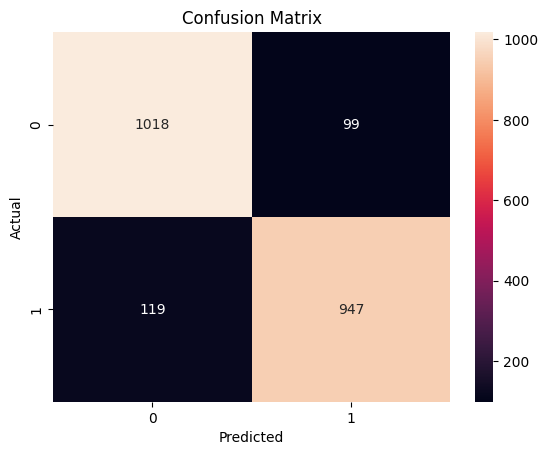

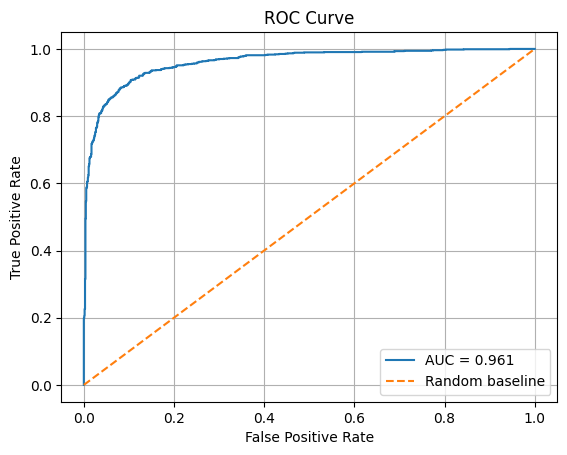

In [103]:
sentiment_best_result_roberta = sentiment_results[100]
print("Best Sentiment Model Metrics")
print("Accuracy", sentiment_best_result_roberta['accuracy'])
print("Macro F1", sentiment_best_result_roberta['macro_f1'])
print("Weighted F1", sentiment_best_result_roberta['weighted_f1'])
print("Precision", sentiment_best_result_roberta['precision'])
print("Recall", sentiment_best_result_roberta['recall'])
print("Classification Report")
print(sentiment_best_result_roberta['classification_report'])
logits = pred_output.predictions
probs = probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = pred_output.label_ids
plot_conf_matrix(y_true, y_pred)
y_scores = probs[:, 1]
plot_roc_curve(y_true, y_scores)



#### Sarcasm

In [105]:
sarcasm_results = {}

seeds = [42,100]

for seed in seeds:
  set_seed(seed)
  model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    problem_type="single_label_classification"
  )

  training_args = TrainingArguments(
      output_dir=f"./results/sarcasm_seed{seed}",
      eval_strategy='no',
      learning_rate=sarc_roberta_results[0]['learning_rate'],
      per_device_train_batch_size=8,
      per_device_eval_batch_size=16,
      num_train_epochs=sarc_roberta_results[0]['num_train_epochs'],
      weight_decay=sarc_roberta_results[0]['weight_decay'],
      seed=seed
  )

  trainer = Trainer(
      model = model,
      args = training_args,
      train_dataset = train_df_sarc,
      data_collator=DataCollatorWithPadding(tokenizer),
      processing_class = tokenizer
  )

  trainer.train()

  pred_output = trainer.predict(test_df_sarc)
  eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
  sarcasm_results[seed] = eval_result

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.371500
1000,0.311674
1500,0.254428


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss
500,0.395493
1000,0.327684
1500,0.282386


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [106]:
pd.DataFrame(sarcasm_results)

,42,100
accuracy,0.872652,0.858452
precision,0.735979,0.690018
recall,0.65823,0.618395
macro_f1,0.684948,0.640335
weighted_f1,0.860176,0.842157
classification_report,precision recall f1-score ...,precision recall f1-score ...


Best Sarcasm Model Metrics
Accuracy 0.858451672010994
Macro F1 0.6403354005275423
Weighted F1 0.842157103494289
Precision 0.6900179326963489
Recall 0.618395048796243
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1878
           1       0.49      0.29      0.36       305

    accuracy                           0.86      2183
   macro avg       0.69      0.62      0.64      2183
weighted avg       0.84      0.86      0.84      2183



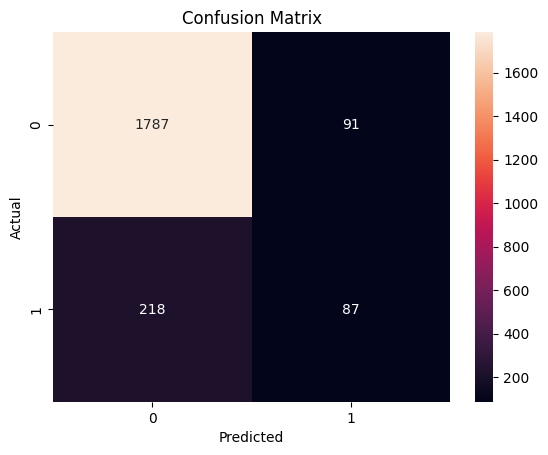

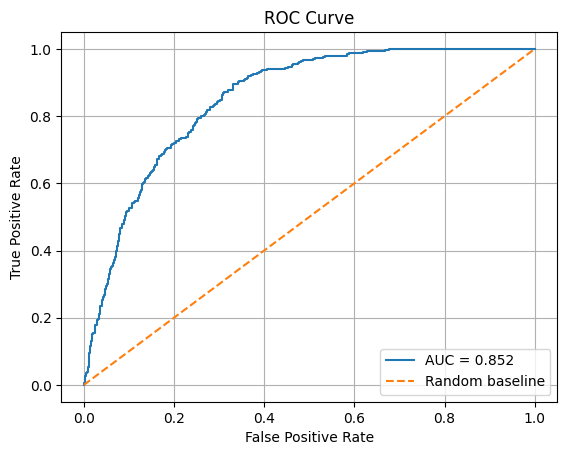

In [107]:
sarcasm_best_result_roberta = sarcasm_results[100]
print("Best Sarcasm Model Metrics")
print("Accuracy", sarcasm_best_result_roberta['accuracy'])
print("Macro F1", sarcasm_best_result_roberta['macro_f1'])
print("Weighted F1", sarcasm_best_result_roberta['weighted_f1'])
print("Precision", sarcasm_best_result_roberta['precision'])
print("Recall", sarcasm_best_result_roberta['recall'])
print("Classification Report")
print(sarcasm_best_result_roberta['classification_report'])
logits = pred_output.predictions
probs = probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = pred_output.label_ids
plot_conf_matrix(y_true, y_pred)
y_scores = probs[:, 1]
plot_roc_curve(y_true, y_scores)



## Bert-base

### Fine-tuning for Sentiment

In [108]:
sent_bert_results = fine_tune_transformer('bert-base-uncased', train_ds_sent, val_ds_sent, candidate_config)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1,Classification Report
1,No log,0.239253,0.907348,0.909536,0.908231,0.907314,0.907274,precision recall f1-score support 0 0.95 0.87 0.91 160 1 0.87 0.95 0.91 153 accuracy 0.91 313 macro avg 0.91 0.91 0.91 313 weighted avg 0.91 0.91 0.91 313
2,0.413974,0.260296,0.910543,0.914078,0.911642,0.910469,0.910412,precision recall f1-score support 0 0.96 0.86 0.91 160 1 0.87 0.96 0.91 153 accuracy 0.91 313 macro avg 0.91 0.91 0.91 313 weighted avg 0.92 0.91 0.91 313
3,0.245210,0.319441,0.929712,0.930390,0.930249,0.929712,0.929707,precision recall f1-score support 0 0.95 0.91 0.93 160 1 0.91 0.95 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [110]:
sent_bert_results.sort(key=lambda x: x['macro_f1'], reverse=True)
pd.DataFrame(sent_bert_results)

,learning_rate,weight_decay,num_train_epochs,macro_f1,weighted_f1,accuracy,precision,recall,classification_report
0,0.00002,0.01,3,0.929712,0.929707,0.929712,0.930390,0.930249,precision recall f1-score ...
1,0.00002,0.10,3,0.929712,0.929707,0.929712,0.930390,0.930249,precision recall f1-score ...
2,0.00001,0.01,2,0.929695,0.929720,0.929712,0.929645,0.929820,precision recall f1-score ...
3,0.00002,0.01,2,0.923322,0.923316,0.923323,0.923995,0.923856,precision recall f1-score ...
4,0.00001,0.10,3,0.923316,0.923332,0.923323,0.923363,0.923570,precision recall f1-score ...
5,0.00002,0.10,2,0.920125,0.920113,0.920128,0.921041,0.920731,precision recall f1-score ...
6,0.00001,0.10,2,0.920098,0.920133,0.920128,0.920056,0.920159,precision recall f1-score ...
7,0.00001,0.01,3,0.916932,0.916938,0.916933,0.917218,0.917320,precision recall f1-score ...


### Fine-tuning for Sarcasm

In [111]:
sarc_bert_results = fine_tune_transformer('bert-base-uncased', train_ds_sarc, val_ds_sarc, candidate_config)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

{'learning_rate': 1e-05, 'num_train_epochs': 2, 'weight_decay': 0.01}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1,Classification Report
1,No log,0.355706,0.862620,0.931090,0.511364,0.485217,0.802066,precision recall f1-score support 0 0.86 1.00 0.93 269 1 1.00 0.02 0.04 44 accuracy 0.86 313 macro avg 0.93 0.51 0.49 313 weighted avg 0.88 0.86 0.80 313
2,0.367268,0.370611,0.843450,0.680171,0.690309,0.684975,0.845592,precision recall f1-score support 0 0.91 0.90 0.91 269 1 0.45 0.48 0.46 44 accuracy 0.84 313 macro avg 0.68 0.69 0.68 313 weighted avg 0.85 0.84 0.85 313
3,0.251056,0.501620,0.872204,0.737939,0.650008,0.678314,0.857842,precision recall f1-score support 0 0.90 0.96 0.93 269 1 0.58 0.34 0.43 44 accuracy 0.87 313 macro avg 0.74 0.65 0.68 313 weighted avg 0.85 0.87 0.86 313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [112]:
sarc_bert_results.sort(key=lambda x:x['macro_f1'], reverse=True)
pd.DataFrame(sarc_bert_results)

,learning_rate,weight_decay,num_train_epochs,macro_f1,weighted_f1,accuracy,precision,recall,classification_report
0,0.00001,0.10,3,0.718390,0.863264,0.862620,0.716376,0.720471,precision recall f1-score ...
1,0.00001,0.01,3,0.717516,0.869327,0.875399,0.742549,0.699392,precision recall f1-score ...
2,0.00002,0.01,3,0.711255,0.863115,0.865815,0.720375,0.703320,precision recall f1-score ...
3,0.00002,0.10,3,0.675580,0.841732,0.840256,0.672447,0.678946,precision recall f1-score ...
4,0.00002,0.10,2,0.670040,0.855701,0.872204,0.739764,0.640504,precision recall f1-score ...
5,0.00002,0.01,2,0.658444,0.848277,0.862620,0.706812,0.634927,precision recall f1-score ...
6,0.00001,0.10,2,0.588158,0.831243,0.865815,0.730205,0.570252,precision recall f1-score ...
7,0.00001,0.01,2,0.574398,0.827559,0.865815,0.737294,0.560747,precision recall f1-score ...


### Running the best Sentiment and Sarcasm model

In [113]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128
    )

train_df_sent = train_val_ds_sent.map(tokenize, batched=True)
test_df_sent = test_ds_sent.map(tokenize, batched=True)
train_df_sarc = train_val_ds_sarc.map(tokenize, batched=True)
test_df_sarc = test_ds_sarc.map(tokenize, batched=True)

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

#### Sentiment

In [114]:
sentiment_results = {}

seeds = [42,100]

for seed in seeds:
  set_seed(seed)
  model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    problem_type="single_label_classification"
  )

  training_args = TrainingArguments(
      output_dir=f"./results/bert_sentiment_seed{seed}",
      eval_strategy='no',
      learning_rate=sent_bert_results[0]['learning_rate'],
      per_device_train_batch_size=8,
      per_device_eval_batch_size=16,
      num_train_epochs=sent_bert_results[0]['num_train_epochs'],
      weight_decay=sent_bert_results[0]['weight_decay'],
      seed=seed
  )

  trainer = Trainer(
      model = model,
      args = training_args,
      train_dataset = train_df_sent,
      data_collator=DataCollatorWithPadding(tokenizer),
      processing_class = tokenizer
  )

  trainer.train()

  pred_output = trainer.predict(test_df_sent)
  eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
  sentiment_results[seed] = eval_result

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.362613
1000,0.228256
1500,0.118522


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss
500,0.358876
1000,0.220449
1500,0.115059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [115]:
pd.DataFrame(sentiment_results)

,42,100
accuracy,0.887311,0.882272
precision,0.887249,0.882267
recall,0.887442,0.882476
macro_f1,0.887285,0.882255
weighted_f1,0.887325,0.882288
classification_report,precision recall f1-score ...,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy 0.8822721026110857
Macro F1 0.8822554001594607
Weighted F1 0.8822881626607252
Precision 0.8822668318543663
Recall 0.8824755064574267
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1117
           1       0.87      0.89      0.88      1066

    accuracy                           0.88      2183
   macro avg       0.88      0.88      0.88      2183
weighted avg       0.88      0.88      0.88      2183



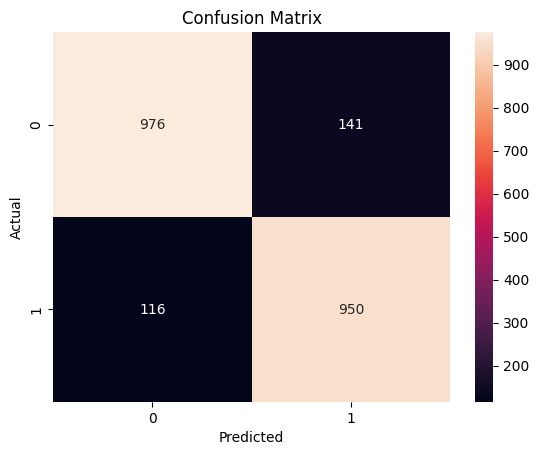

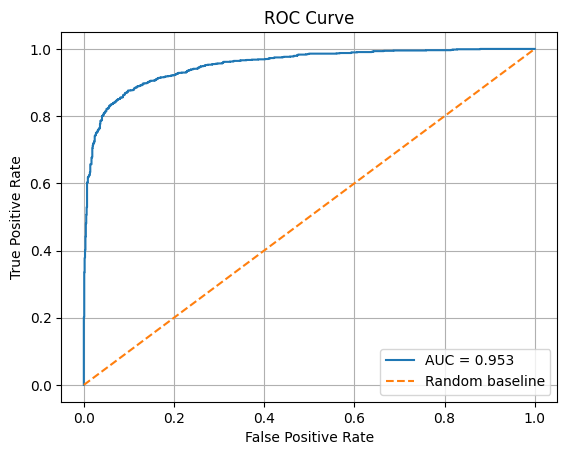

In [116]:
sentiment_best_result_bert = sentiment_results[100]
print("Best Sentiment Model Metrics")
print("Accuracy", sentiment_best_result_bert['accuracy'])
print("Macro F1", sentiment_best_result_bert['macro_f1'])
print("Weighted F1", sentiment_best_result_bert['weighted_f1'])
print("Precision", sentiment_best_result_bert['precision'])
print("Recall", sentiment_best_result_bert['recall'])
print("Classification Report")
print(sentiment_best_result_bert['classification_report'])
logits = pred_output.predictions
probs = probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = pred_output.label_ids
plot_conf_matrix(y_true, y_pred)
y_scores = probs[:, 1]
plot_roc_curve(y_true, y_scores)



#### Sarcasm

In [117]:
sarcasm_results = {}

seeds = [42,100]

for seed in seeds:
  set_seed(seed)
  model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    problem_type="single_label_classification"
  )

  training_args = TrainingArguments(
      output_dir=f"./results/bert_sarcasm_seed{seed}",
      eval_strategy='no',
      learning_rate=sarc_bert_results[0]['learning_rate'],
      per_device_train_batch_size=8,
      per_device_eval_batch_size=16,
      num_train_epochs=sarc_bert_results[0]['num_train_epochs'],
      weight_decay=sarc_bert_results[0]['weight_decay'],
      seed=seed
  )

  trainer = Trainer(
      model = model,
      args = training_args,
      train_dataset = train_df_sarc,
      data_collator=DataCollatorWithPadding(tokenizer),
      processing_class = tokenizer
  )

  trainer.train()

  pred_output = trainer.predict(test_df_sarc)
  eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
  sarcasm_results[seed] = eval_result

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.340565
1000,0.279501
1500,0.204430


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss
500,0.355862
1000,0.279687
1500,0.224776


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [118]:
pd.DataFrame(sarcasm_results)

,42,100
accuracy,0.856619,0.862116
precision,0.692476,0.703224
recall,0.654404,0.635629
macro_f1,0.669806,0.658284
weighted_f1,0.848769,0.848455
classification_report,precision recall f1-score ...,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy 0.8621163536417774
Macro F1 0.6582841582968995
Weighted F1 0.8484550024709758
Precision 0.703224405658798
Recall 0.6356291136367604
Classification Report
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1878
           1       0.51      0.32      0.39       305

    accuracy                           0.86      2183
   macro avg       0.70      0.64      0.66      2183
weighted avg       0.84      0.86      0.85      2183



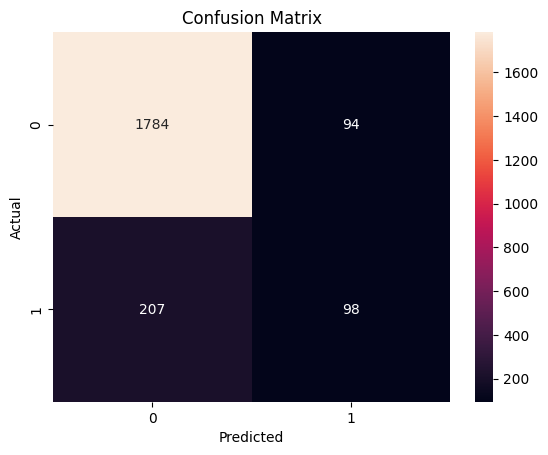

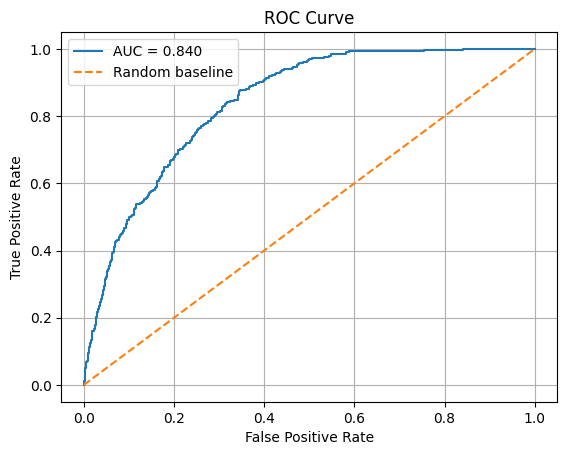

In [119]:
sarcasm_best_result_bert = sarcasm_results[100]
print("Best Sentiment Model Metrics")
print("Accuracy", sarcasm_best_result_bert['accuracy'])
print("Macro F1", sarcasm_best_result_bert['macro_f1'])
print("Weighted F1", sarcasm_best_result_bert['weighted_f1'])
print("Precision", sarcasm_best_result_bert['precision'])
print("Recall", sarcasm_best_result_bert['recall'])
print("Classification Report")
print(sarcasm_best_result_bert['classification_report'])
logits = pred_output.predictions
probs = probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = pred_output.label_ids
plot_conf_matrix(y_true, y_pred)
y_scores = probs[:, 1]
plot_roc_curve(y_true, y_scores)



## DistilBERT-base

### Fine-tuning for Sentiment

In [120]:
sent_distilbert_results = fine_tune_transformer('distilbert-base-uncased', train_ds_sent, val_ds_sent, candidate_config)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1,Classification Report
1,No log,0.248986,0.894569,0.896709,0.895445,0.894530,0.894485,precision recall f1-score support 0 0.93 0.86 0.89 160 1 0.86 0.93 0.90 153 accuracy 0.89 313 macro avg 0.90 0.90 0.89 313 weighted avg 0.90 0.89 0.89 313
2,0.422915,0.281156,0.897764,0.902253,0.898999,0.897637,0.897557,precision recall f1-score support 0 0.95 0.84 0.89 160 1 0.85 0.95 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.90 0.90 0.90 313
3,0.243611,0.283874,0.913738,0.915228,0.914481,0.913724,0.913699,precision recall f1-score support 0 0.95 0.88 0.91 160 1 0.88 0.95 0.91 153 accuracy 0.91 313 macro avg 0.92 0.91 0.91 313 weighted avg 0.92 0.91 0.91 313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [121]:
sent_distilbert_results.sort(key=lambda x: x['macro_f1'], reverse=True)
pd.DataFrame(sent_distilbert_results)

,learning_rate,weight_decay,num_train_epochs,macro_f1,weighted_f1,accuracy,precision,recall,classification_report
0,0.00002,0.01,2,0.913734,0.913747,0.913738,0.913883,0.914052,precision recall f1-score ...
1,0.00002,0.10,2,0.913734,0.913747,0.913738,0.913883,0.914052,precision recall f1-score ...
2,0.00002,0.10,3,0.913724,0.913699,0.913738,0.915228,0.914481,precision recall f1-score ...
3,0.00001,0.01,3,0.910542,0.910536,0.910543,0.911205,0.911070,precision recall f1-score ...
4,0.00002,0.01,3,0.910535,0.910516,0.910543,0.911718,0.911213,precision recall f1-score ...
5,0.00001,0.10,3,0.907344,0.907331,0.907348,0.908245,0.907945,precision recall f1-score ...
6,0.00001,0.01,2,0.904152,0.904159,0.904153,0.904435,0.904534,precision recall f1-score ...
7,0.00001,0.10,2,0.904145,0.904165,0.904153,0.904193,0.904391,precision recall f1-score ...


### Fine-tuning for Sarcasm

In [122]:
sarc_distilbert_results = fine_tune_transformer('distilbert-base-uncased', train_ds_sarc, val_ds_sarc, candidate_config)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

{'learning_rate': 1e-05, 'num_train_epochs': 2, 'weight_decay': 0.01}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1,Classification Report
1,No log,0.354851,0.859425,0.429712,0.500000,0.462199,0.794451,precision recall f1-score support 0 0.86 1.00 0.92 269 1 0.00 0.00 0.00 44 accuracy 0.86 313 macro avg 0.43 0.50 0.46 313 weighted avg 0.74 0.86 0.79 313
2,0.367196,0.323608,0.840256,0.672447,0.678946,0.675580,0.841732,precision recall f1-score support 0 0.91 0.90 0.91 269 1 0.43 0.45 0.44 44 accuracy 0.84 313 macro avg 0.67 0.68 0.68 313 weighted avg 0.84 0.84 0.84 313
3,0.261200,0.452305,0.856230,0.696142,0.669229,0.680938,0.850941,precision recall f1-score support 0 0.91 0.93 0.92 269 1 0.49 0.41 0.44 44 accuracy 0.86 313 macro avg 0.70 0.67 0.68 313 weighted avg 0.85 0.86 0.85 313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [123]:
sarc_distilbert_results.sort(key=lambda x: x['macro_f1'], reverse=True)
pd.DataFrame(sarc_distilbert_results)

,learning_rate,weight_decay,num_train_epochs,macro_f1,weighted_f1,accuracy,precision,recall,classification_report
0,0.00002,0.01,3,0.684975,0.845592,0.843450,0.680171,0.690309,precision recall f1-score ...
1,0.00001,0.10,3,0.684707,0.853426,0.859425,0.703069,0.671088,precision recall f1-score ...
2,0.00002,0.10,3,0.680938,0.850941,0.856230,0.696142,0.669229,precision recall f1-score ...
3,0.00001,0.01,3,0.674056,0.849223,0.856230,0.694296,0.659725,precision recall f1-score ...
4,0.00002,0.01,2,0.630062,0.836519,0.853035,0.675020,0.610341,precision recall f1-score ...
5,0.00002,0.10,2,0.626672,0.834163,0.849840,0.666278,0.608483,precision recall f1-score ...
6,0.00001,0.01,2,0.617104,0.836069,0.859425,0.691980,0.595049,precision recall f1-score ...
7,0.00001,0.10,2,0.617104,0.836069,0.859425,0.691980,0.595049,precision recall f1-score ...


### Running the best Sentiment and Sarcasm model

In [124]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128
    )

train_df_sent = train_val_ds_sent.map(tokenize, batched=True)
test_df_sent = test_ds_sent.map(tokenize, batched=True)
train_df_sarc = train_val_ds_sarc.map(tokenize, batched=True)
test_df_sarc = test_ds_sarc.map(tokenize, batched=True)

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/4060 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

#### Sentiment

In [125]:
sentiment_results = {}

seeds = [42,100]

for seed in seeds:
  set_seed(seed)
  model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    problem_type="single_label_classification"
  )

  training_args = TrainingArguments(
      output_dir=f"./results/distilbert_sentiment_seed{seed}",
      eval_strategy='no',
      learning_rate=sarc_distilbert_results[0]['learning_rate'],
      per_device_train_batch_size=8,
      per_device_eval_batch_size=16,
      num_train_epochs=sarc_distilbert_results[0]['num_train_epochs'],
      weight_decay=sarc_distilbert_results[0]['weight_decay'],
      seed=seed
  )

  trainer = Trainer(
      model = model,
      args = training_args,
      train_dataset = train_df_sent,
      data_collator=DataCollatorWithPadding(tokenizer),
      processing_class = tokenizer
  )

  trainer.train()

  pred_output = trainer.predict(test_df_sent)
  eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
  sentiment_results[seed] = eval_result

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.369176
1000,0.240912
1500,0.150336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss
500,0.382194
1000,0.248277
1500,0.155615


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [126]:
pd.DataFrame(sentiment_results)

,42,100
accuracy,0.872652,0.874943
precision,0.872603,0.874852
recall,0.872797,0.874949
macro_f1,0.872627,0.874892
weighted_f1,0.872669,0.874951
classification_report,precision recall f1-score ...,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy 0.874942739349519
Macro F1 0.8748919136619242
Weighted F1 0.8749508252543637
Precision 0.8748524386455421
Recall 0.8749494004477956
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1117
           1       0.87      0.88      0.87      1066

    accuracy                           0.87      2183
   macro avg       0.87      0.87      0.87      2183
weighted avg       0.87      0.87      0.87      2183



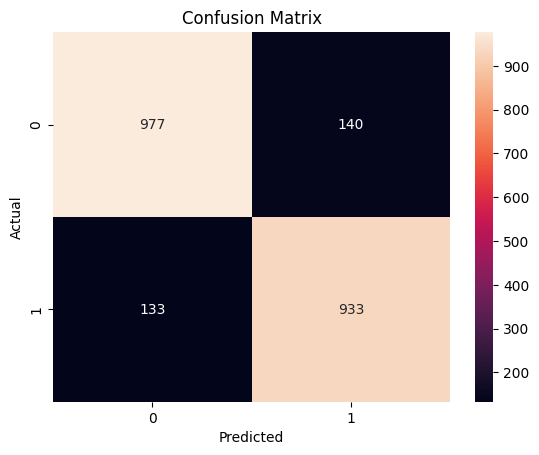

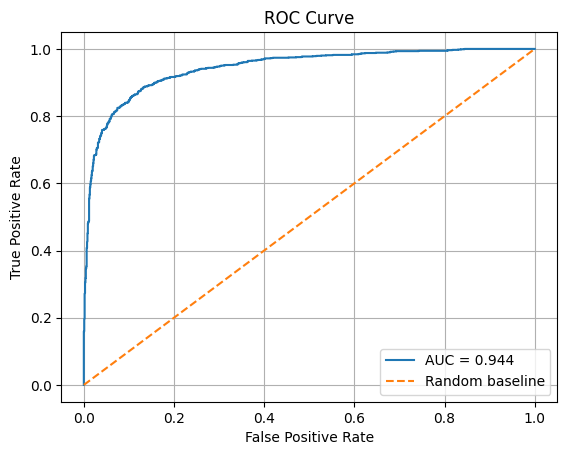

In [127]:
sentiment_best_result_distilbert = sentiment_results[100]
print("Best Sentiment Model Metrics")
print("Accuracy", sentiment_best_result_distilbert['accuracy'])
print("Macro F1", sentiment_best_result_distilbert['macro_f1'])
print("Weighted F1", sentiment_best_result_distilbert['weighted_f1'])
print("Precision", sentiment_best_result_distilbert['precision'])
print("Recall", sentiment_best_result_distilbert['recall'])
print("Classification Report")
print(sentiment_best_result_distilbert['classification_report'])
logits = pred_output.predictions
probs = probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = pred_output.label_ids
plot_conf_matrix(y_true, y_pred)
y_scores = probs[:, 1]
plot_roc_curve(y_true, y_scores)

#### Sarcasm

In [128]:
sarcasm_results = {}

seeds = [42,100]

for seed in seeds:
  set_seed(seed)
  model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    problem_type="single_label_classification"
  )

  training_args = TrainingArguments(
      output_dir=f"./results/distilbert_sarcasm_seed{seed}",
      eval_strategy='no',
      learning_rate=sarc_distilbert_results[0]['learning_rate'],
      per_device_train_batch_size=8,
      per_device_eval_batch_size=16,
      num_train_epochs=sarc_distilbert_results[0]['num_train_epochs'],
      weight_decay=sarc_distilbert_results[0]['weight_decay'],
      seed=seed
  )

  trainer = Trainer(
      model = model,
      args = training_args,
      train_dataset = train_df_sarc,
      data_collator=DataCollatorWithPadding(tokenizer),
      processing_class = tokenizer
  )

  trainer.train()

  pred_output = trainer.predict(test_df_sarc)
  eval_result = compute_metrics_transfomer((pred_output.predictions, pred_output.label_ids))
  sarcasm_results[seed] = eval_result

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.338997
1000,0.267888
1500,0.176470


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss
500,0.370317
1000,0.275583
1500,0.195246


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [129]:
pd.DataFrame(sarcasm_results)

,42,100
accuracy,0.857994,0.859368
precision,0.692082,0.691937
recall,0.635979,0.613435
macro_f1,0.655881,0.636046
weighted_f1,0.845913,0.841476
classification_report,precision recall f1-score ...,precision recall f1-score ...


Best Sentiment Model Metrics
Accuracy 0.8593678424186899
Macro F1 0.6360459414061885
Weighted F1 0.8414759708171035
Precision 0.6919369608885738
Recall 0.6134351158365194
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1878
           1       0.49      0.27      0.35       305

    accuracy                           0.86      2183
   macro avg       0.69      0.61      0.64      2183
weighted avg       0.83      0.86      0.84      2183



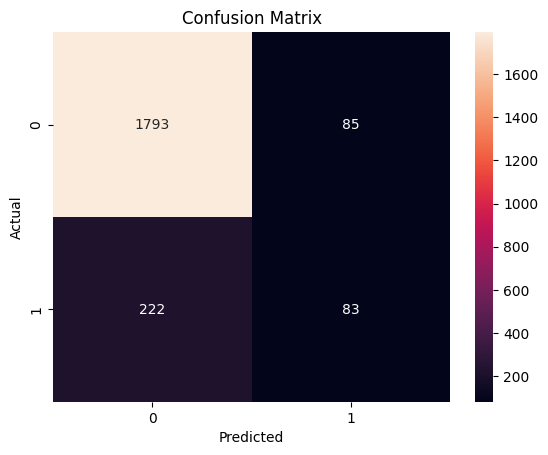

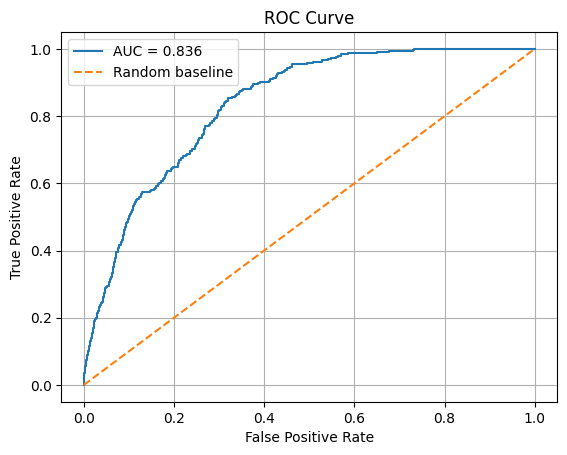

In [130]:
sarcasm_best_result_distilbert = sarcasm_results[100]
print("Best Sentiment Model Metrics")
print("Accuracy", sarcasm_best_result_distilbert['accuracy'])
print("Macro F1", sarcasm_best_result_distilbert['macro_f1'])
print("Weighted F1", sarcasm_best_result_distilbert['weighted_f1'])
print("Precision", sarcasm_best_result_distilbert['precision'])
print("Recall", sarcasm_best_result_distilbert['recall'])
print("Classification Report")
print(sarcasm_best_result_distilbert['classification_report'])
logits = pred_output.predictions
probs = probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(probs, axis=1)
y_true = pred_output.label_ids
plot_conf_matrix(y_true, y_pred)
y_scores = probs[:, 1]
plot_roc_curve(y_true, y_scores)

# Final Results of baseline models and transformers

In [143]:
all_sentiment_results = {
    'TF-IDF + Logistic Regression' : {
        'Accuracy': sentiment_best_result_lr['accuracy'],
        'Macro F1': sentiment_best_result_lr['macro_f1'],
        'Weighted F1': sentiment_best_result_lr['weighted_f1'],
        'Precision': sentiment_best_result_lr['precision'],
        'Recall': sentiment_best_result_lr['recall']
    },
    'TF-IDF + Linear SVC' : {
        'Accuracy': sentiment_best_result_svc['accuracy'],
        'Macro F1': sentiment_best_result_svc['macro_f1'],
        'Weighted F1': sentiment_best_result_svc['weighted_f1'],
        'Precision': sentiment_best_result_svc['precision'],
        'Recall': sentiment_best_result_svc['recall']
    },
    'TF-IDF + Multinomial NB' : {
        'Accuracy': sentiment_best_result_nb['accuracy'],
        'Macro F1': sentiment_best_result_nb['macro_f1'],
        'Weighted F1': sentiment_best_result_nb['weighted_f1'],
        'Precision': sentiment_best_result_nb['precision'],
        'Recall': sentiment_best_result_nb['recall']
    },
    'RoBERTa' : {
        'Accuracy': sentiment_best_result_roberta['accuracy'],
        'Macro F1': sentiment_best_result_roberta['macro_f1'],
        'Weighted F1': sentiment_best_result_roberta['weighted_f1'],
        'Precision': sentiment_best_result_roberta['precision'],
        'Recall': sentiment_best_result_roberta['recall']
    },
    'BERT' : {
        'Accuracy': sentiment_best_result_bert['accuracy'],
        'Macro F1': sentiment_best_result_bert['macro_f1'],
        'Weighted F1': sentiment_best_result_bert['weighted_f1'],
        'Precision': sentiment_best_result_bert['precision'],
        'Recall': sentiment_best_result_bert['recall']
    },
    'DistilBERT' : {
        'Accuracy': sentiment_best_result_distilbert['accuracy'],
        'Macro F1': sentiment_best_result_distilbert['macro_f1'],
        'Weighted F1': sentiment_best_result_distilbert['weighted_f1'],
        'Precision': sentiment_best_result_distilbert['precision'],
        'Recall': sentiment_best_result_distilbert['recall']
    }
}

all_sarcasm_results = {
    'TF-IDF + Logistic Regression' : {
        'Accuracy': sarcasm_best_result_lr['accuracy'],
        'Macro F1': sarcasm_best_result_lr['macro_f1'],
        'Weighted F1': sarcasm_best_result_lr['weighted_f1'],
        'Precision': sarcasm_best_result_lr['precision'],
        'Recall': sarcasm_best_result_lr['recall']
    },
    'TF-IDF + Linear SVC' : {
        'Accuracy': sarcasm_best_result_svc['accuracy'],
        'Macro F1': sarcasm_best_result_svc['macro_f1'],
        'Weighted F1': sarcasm_best_result_svc['weighted_f1'],
        'Precision': sarcasm_best_result_svc['precision'],
        'Recall': sarcasm_best_result_svc['recall']
    },
    'TF-IDF + Multinomial NB' : {
        'Accuracy': sarcasm_best_result_nb['accuracy'],
        'Macro F1': sarcasm_best_result_nb['macro_f1'],
        'Weighted F1': sarcasm_best_result_nb['weighted_f1'],
        'Precision': sarcasm_best_result_nb['precision'],
        'Recall': sarcasm_best_result_nb['recall']
    },
    'RoBERTa' : {
        'Accuracy': sarcasm_best_result_roberta['accuracy'],
        'Macro F1': sarcasm_best_result_roberta['macro_f1'],
        'Weighted F1': sarcasm_best_result_roberta['weighted_f1'],
        'Precision': sarcasm_best_result_roberta['precision'],
        'Recall': sarcasm_best_result_roberta['recall']
    },
    'BERT' : {
        'Accuracy': sarcasm_best_result_bert['accuracy'],
        'Macro F1': sarcasm_best_result_bert['macro_f1'],
        'Weighted F1': sarcasm_best_result_bert['weighted_f1'],
        'Precision': sarcasm_best_result_bert['precision'],
        'Recall': sarcasm_best_result_bert['recall']
    },
    'DistilBERT' : {
        'Accuracy': sarcasm_best_result_distilbert['accuracy'],
        'Macro F1': sarcasm_best_result_distilbert['macro_f1'],
        'Weighted F1': sarcasm_best_result_distilbert['weighted_f1'],
        'Precision': sarcasm_best_result_distilbert['precision'],
        'Recall': sarcasm_best_result_distilbert['recall']
    }
  }


In [146]:
sorted_sentiment_results = dict(
    sorted(
        all_sentiment_results.items(),
        key=lambda x: x[1]['Macro F1'],
        reverse=True
    )
)

pd.DataFrame(sorted_sentiment_results).T

,Accuracy,Macro F1,Weighted F1,Precision,Recall
RoBERTa,0.900137,0.900032,0.900108,0.900346,0.899869
BERT,0.882272,0.882255,0.882288,0.882267,0.882476
DistilBERT,0.874943,0.874892,0.874951,0.874852,0.874949
TF-IDF + Logistic Regression,0.835089,0.834511,0.834740,0.837012,0.834164
TF-IDF + Linear SVC,0.829592,0.828729,0.829013,0.832892,0.828386
TF-IDF + Multinomial NB,0.808520,0.808509,0.808544,0.808630,0.808780


In [147]:
sorted_sarcasm_results = dict(
    sorted(
        all_sarcasm_results.items(),
        key=lambda x: x[1]['Macro F1'],
        reverse=True
    )
)

pd.DataFrame(sorted_sarcasm_results).T

,Accuracy,Macro F1,Weighted F1,Precision,Recall
BERT,0.862116,0.658284,0.848455,0.703224,0.635629
RoBERTa,0.858452,0.640335,0.842157,0.690018,0.618395
DistilBERT,0.859368,0.636046,0.841476,0.691937,0.613435
TF-IDF + Logistic Regression,0.744388,0.624070,0.777318,0.615919,0.700396
TF-IDF + Linear SVC,0.731104,0.615222,0.767378,0.611061,0.698168
TF-IDF + Multinomial NB,0.731104,0.611854,0.766879,0.607497,0.689929
